In [1]:
import pandas as pd
import numpy as np
import os
import openpyxl
import matplotlib.pyplot as plt

# Load data

In [2]:
input_dir = "/mnt/c/users/helen/Desktop/test"

In [3]:
dfs = []

for root, dirs, files in os.walk(input_dir):
    for filename in files:
        if filename.lower().endswith(".csv"):

            path = os.path.join(root, filename)

            df = pd.read_csv(path)

            # Optional metadata
            df["File"] = os.path.splitext(filename)[0].replace(" ", "_")
            df["Path"] = path

            dfs.append(df) 

# Combine all tables
data = pd.concat(dfs, ignore_index=True)

# Create ROI column
data['ROI'] = data['Label'].apply(lambda x: x.split(":")[1])

# Delete first 3 columns
data.drop(data.columns[[0, 1, 2]], axis=1, inplace=True)

# Reorder columns
data = data[
    [
        "File",
        "Measurement_type",
        "Length",
        "ROI",
        "Path"
    ]
]

# Split data into 2 dataframes
speed = data[data['Measurement_type']=='Fiber_length']
iod = data[data['Measurement_type']=='Interorigin_distance']

# Process replication speed

In [4]:
conversion_factor = 2.59 # kb/µm
time = 20 # minutes

In [5]:
# Checking speed file
counts = speed.groupby("File").size()
odd_files = counts[counts % 2 != 0].index.tolist()

if len(odd_files) == 0:
    print("All files contain an even number of fibers.")
else:
    print("The following files contain an odd number of fibers will be removed:")
    print(*odd_files, sep="\n")
    
    # Removing odd files from speed dataframe
    speed = speed[~speed["File"].isin(odd_files)].copy()

All files contain an even number of fibers.


In [6]:
# Add extra inedex to group pairs of files
speed["Index"] = speed.groupby("File").cumcount() // 2

# Calculate sum of fiber length in pairs
speed_processed = speed.groupby(["File", "Index"], as_index=False).agg(
        Total_Length=("Length", "sum"),
        ROI=("ROI", list),
        Path=("Path", "first"),
        )

# Convert speed to kb/min
speed_processed['Speed_kb_min'] = speed_processed['Total_Length'].apply(lambda x: x * conversion_factor / time)

# Delete extra columns
replication_speed = speed_processed[['File', 'Speed_kb_min', 'ROI', 'Path']]

# Info
n_fibers = len(replication_speed)
print(f"The amount of fibers is: {n_fibers}")

The amount of fibers is: 4


In [7]:
replication_speed

,File,Speed_kb_min,ROI,Path
0,siORC1_MGS1-14_Fiber_length,31.572618,"[0549-0366, 0448-0508]",/mnt/c/users/helen/Desktop/test/siORC1_MGS1-14...
1,siORC1_MGS1-14_Fiber_length,28.596449,"[0318-0501, 0235-0613]",/mnt/c/users/helen/Desktop/test/siORC1_MGS1-14...
2,siORC1_MGS1-14_Fiber_length,37.271525,"[0209-0494, 0085-0630]",/mnt/c/users/helen/Desktop/test/siORC1_MGS1-14...
3,siORC1_MGS1-15_Fiber_length,41.585299,"[0659-0571, 0574-0747]",/mnt/c/users/helen/Desktop/test/siORC1_MGS1-15...


# Process IOD

In [8]:
iod['IOD_kb'] = iod['Length'].apply(lambda x: x * conversion_factor)
iod_kb = iod[["File", 'IOD_kb', 'ROI', 'Path']]

# Info
n_origins = len(iod_kb)
print(f"The amount of origins is: {n_origins}")

The amount of origins is: 4


In [9]:
iod_kb

,File,IOD_kb,ROI,Path
6,siORC1_MGS1-14_Interorigin_distance,1005.32145,0635-0591,/mnt/c/users/helen/Desktop/test/siORC1_MGS1-14...
9,siORC1_MGS1-15_Interorigin_distance,588.10612,0409-0567,/mnt/c/users/helen/Desktop/test/siORC1_MGS1-15...
10,siORC1_MGS1-15_Interorigin_distance,703.05032,0574-0537,/mnt/c/users/helen/Desktop/test/siORC1_MGS1-15...
11,siORC1_MGS1-15_Interorigin_distance,535.84769,0708-0551,/mnt/c/users/helen/Desktop/test/siORC1_MGS1-15...


# Graphs

## Replication speed graph

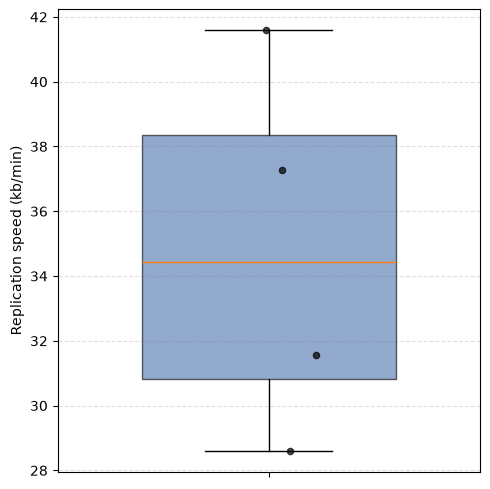

Plot is saved in the directory: /mnt/c/users/helen/Desktop/test


In [ ]:
plt.figure(figsize=(5, 5))

values = replication_speed["Speed_kb_min"]

bp = plt.boxplot(
    values,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
)

for box in bp["boxes"]:
    box.set(facecolor="#4C72B0", alpha=0.6)

# Jittered dots
x = np.random.normal(1, 0.05, len(values))
plt.scatter(x, values, s=20, color="black", alpha=0.7, zorder=3)

plt.ylabel("Replication speed (kb/min)")
plt.xticks([1], [""])
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{input_dir}/replication_speed_boxplot.png", dpi=600, bbox_inches="tight")
print(f"Plot is saved in the directory: {input_dir}")

plt.show()

## IOD graph

Plot is saved in the directory: /mnt/c/users/helen/Desktop/test


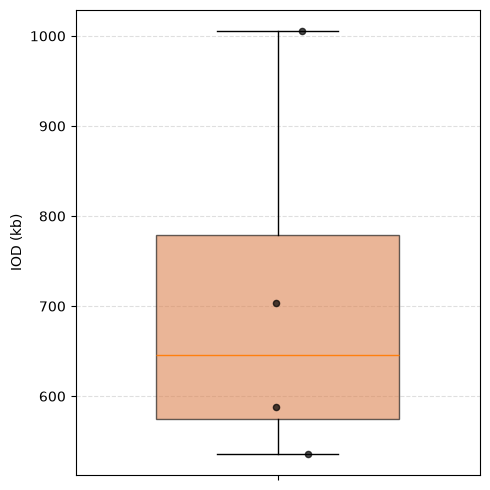

In [13]:
plt.figure(figsize=(5, 5))

values = iod_kb["IOD_kb"]

bp = plt.boxplot(
    values,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
)

for box in bp["boxes"]:
    box.set(facecolor="#DD8452", alpha=0.6)

# Jittered dots
x = np.random.normal(1, 0.05, len(values))
plt.scatter(x, values, s=20, color="black", alpha=0.7, zorder=3)

plt.ylabel("IOD (kb)")
plt.xticks([1], [""])
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{input_dir}/iod_boxplot.png", dpi=600, bbox_inches="tight")
print(f"Plot is saved in the directory: {input_dir}")

plt.show()

# Data export

In [12]:

replication_speed.to_excel(f"{input_dir}/replication_speed.xlsx", index=False)
iod_kb.to_excel(f"{input_dir}/iod_kb.xlsx", index=False)